# Application 2 — House Price Prediction
### Assignment 02 — Intelligent System Development (PTIT)

**Pipeline:** `Raw Data -> Understand -> Clean -> Represent -> Learn -> Evaluate -> Persist -> Deploy`

**Dataset:** Vietnam Housing Dataset — real-estate listings scraped from a Vietnamese property
portal (`data/vietnam_housing.csv`). One observation = **one house/apartment listing**.

- `X` = characteristics of the house (area, frontage, floors, bedrooms, bathrooms, legal
  status, furniture state, directions, province...)
- `y` = `Price` (billion VND)

This is a **regression** problem: the target is a continuous numerical value.


In [1]:
import json
import os
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid")

DATA_PATH = "../data/vietnam_housing.csv"
CHART_DIR = "../charts"
MODEL_DIR = "../model"
os.makedirs(CHART_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

## 1–2. Raw Data & Data Understanding

Kaggle-style dataset (30,229 rows x 12 columns). Each row is a listing scraped from an
online real-estate portal; `Address` is a free-text string, `Price` is the sale price in
billion VND.

In [2]:
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (30229, 12)


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30229 entries, 0 to 30228
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Address            30229 non-null  str    
 1   Area               30229 non-null  float64
 2   Frontage           18665 non-null  float64
 3   Access Road        16932 non-null  float64
 4   House direction    8990 non-null   str    
 5   Balcony direction  5246 non-null   str    
 6   Floors             26626 non-null  float64
 7   Bedrooms           25067 non-null  float64
 8   Bathrooms          23155 non-null  float64
 9   Legal status       25723 non-null  str    
 10  Furniture state    16110 non-null  str    
 11  Price              30229 non-null  float64
dtypes: float64(7), str(5)
memory usage: 2.8 MB


In [4]:
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicated rows:", df.duplicated().sum())
df.describe()

Missing values per column:
Address                  0
Area                     0
Frontage             11564
Access Road          13297
House direction      21239
Balcony direction    24983
Floors                3603
Bedrooms              5162
Bathrooms             7074
Legal status          4506
Furniture state      14119
Price                    0
dtype: int64

Duplicated rows: 0


,Area,Frontage,Access Road,Floors,Bedrooms,Bathrooms,Price
count,30229.000000,18665.000000,16932.000000,26626.000000,25067.000000,23155.000000,30229.000000
mean,68.498741,5.361692,7.853800,3.410426,3.511030,3.346837,5.872078
std,48.069835,4.346174,7.451313,1.328897,1.309116,1.400181,2.211877
min,3.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,40.000000,4.000000,4.000000,2.000000,3.000000,2.000000,4.200000
50%,56.000000,4.500000,6.000000,3.000000,3.000000,3.000000,5.900000
75%,80.000000,5.000000,10.000000,4.000000,4.000000,4.000000,7.500000
max,595.000000,77.000000,85.000000,10.000000,9.000000,9.000000,11.500000


**Observations.** `Area` and `Price` have no missing values (the two columns the crawler
always captured). `Frontage`, `Access Road`, `House direction`, `Balcony direction`,
`Legal status`, `Furniture state` are missing for a large share of listings — a common
situation with crowd-submitted real-estate ads, where the seller may skip optional fields.
There are no fully duplicated rows.

## 3. Data Cleaning

- No exact duplicate rows to remove.
- Invalid-value checks (`Area<=0`, `Price<=0`, `Floors<=0`, `Bedrooms<=0`, `Bathrooms<=0`)
  find **zero** violations, so no rows are dropped on this basis.
- Outliers (IQR method) are **kept**: an expensive villa with a large `Area` is a real,
  informative observation for a price-prediction model, not a data-entry error.
- **Feature engineering:** `Address` is a long free-text string ("Dự án ..., Xã ..., Huyện ...,
  Tỉnh/TP"); the last comma-separated segment is extracted as the **province/city**, then
  grouped into the 12 most frequent provinces + `"Khac"` ("Other") to keep the one-hot
  encoding compact.
- Missing **categorical** values are recoded as the explicit category `"Unknown"` rather than
  dropped, because "no information reported" is itself a meaningful signal for a listing.


In [5]:
df_clean = df.drop_duplicates().copy()

invalid_checks = {
    "Area <= 0": (df_clean["Area"] <= 0).sum(),
    "Price <= 0": (df_clean["Price"] <= 0).sum(),
    "Floors <= 0": (df_clean["Floors"] <= 0).sum(),
    "Bedrooms <= 0": (df_clean["Bedrooms"] <= 0).sum(),
    "Bathrooms <= 0": (df_clean["Bathrooms"] <= 0).sum(),
}
print("Invalid value counts:", invalid_checks)

outlier_summary = []
for col in ["Area", "Frontage", "Access Road", "Price"]:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_summary.append({"feature": col, "lower": lower, "upper": upper, "outliers": n_out})
pd.DataFrame(outlier_summary)

Invalid value counts: {'Area <= 0': np.int64(0), 'Price <= 0': np.int64(0), 'Floors <= 0': np.int64(0), 'Bedrooms <= 0': np.int64(0), 'Bathrooms <= 0': np.int64(0)}


,feature,lower,upper,outliers
0,Area,-20.00,140.00,1636
1,Frontage,2.50,6.50,2305
2,Access Road,-5.00,19.00,1110
3,Price,-0.75,12.45,0


In [6]:
def extract_province(addr: str) -> str:
    parts = [p.strip().rstrip(".").strip() for p in str(addr).split(",")]
    return parts[-1] if parts and parts[-1] else "Unknown"

df_clean["Province"] = df_clean["Address"].apply(extract_province)
top_provinces = df_clean["Province"].value_counts().head(12).index.tolist()
df_clean["ProvinceGroup"] = df_clean["Province"].where(df_clean["Province"].isin(top_provinces), "Khac")

numeric_features = ["Area", "Frontage", "Access Road", "Floors", "Bedrooms", "Bathrooms"]
categorical_features = ["Legal status", "Furniture state", "House direction", "Balcony direction", "ProvinceGroup"]
target_col = "Price"

for c in categorical_features:
    df_clean[c] = df_clean[c].fillna("Unknown")

print("Cleaned dataset shape:", df_clean.shape)
df_clean["ProvinceGroup"].value_counts()

Cleaned dataset shape: (30229, 14)


ProvinceGroup
Hồ Chí Minh        11778
Hà Nội             10457
Bình Dương          1672
Đà Nẵng             1437
Khac                1246
Đồng Nai             829
Hải Phòng            789
Khánh Hòa            743
Hưng Yên             405
Long An              339
Bà Rịa Vũng Tàu      240
Bắc Ninh             167
Bình Thuận           127
Name: count, dtype: int64

## 4. Data Representation

Every observation is converted into a numerical **feature vector**
`x = [Area, Frontage, AccessRoad, Floors, Bedrooms, Bathrooms, LegalStatus, Furniture,
HouseDirection, BalconyDirection, ProvinceGroup]^T`, and the whole dataset becomes a
**feature matrix** `X ∈ R^(N×d)`.

In [7]:
feature_cols = numeric_features + categorical_features
X = df_clean[feature_cols].copy()
y = df_clean[target_col].copy()
print("X shape:", X.shape, " (N =", X.shape[0], ", d =", X.shape[1], ")")
print("y shape:", y.shape)
X.dtypes

X shape: (30229, 11)  (N = 30229 , d = 11 )
y shape: (30229,)


Area                 float64
Frontage             float64
Access Road          float64
Floors               float64
Bedrooms             float64
Bathrooms            float64
Legal status             str
Furniture state          str
House direction          str
Balcony direction        str
ProvinceGroup            str
dtype: object

## 5. Exploratory Data Analysis (EDA)

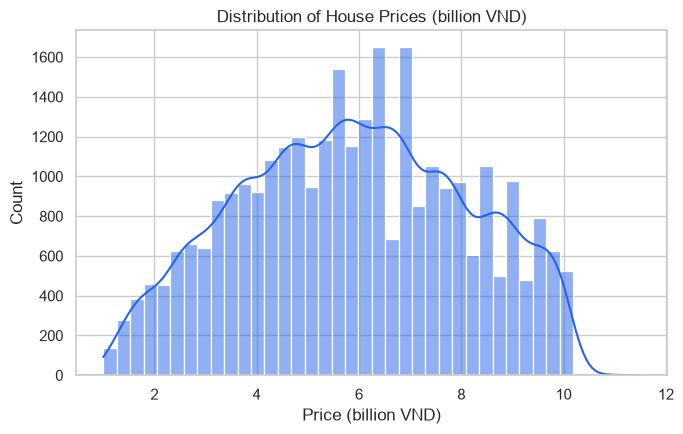

In [8]:
plt.figure(figsize=(7, 4.5))
sns.histplot(y, bins=40, kde=True, color="#2563eb")
plt.title("Distribution of House Prices (billion VND)")
plt.xlabel("Price (billion VND)")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/01_price_distribution.png", dpi=120)
plt.show()

**Observation:** `Price` is right-skewed with a long tail toward high-end listings.
**Interpretation:** most listings cluster in the 3–8 billion VND range, with a smaller number
of premium properties. **ML implication:** tree-based models (which do not assume a Gaussian
target) are expected to cope with this skew better than plain linear models.

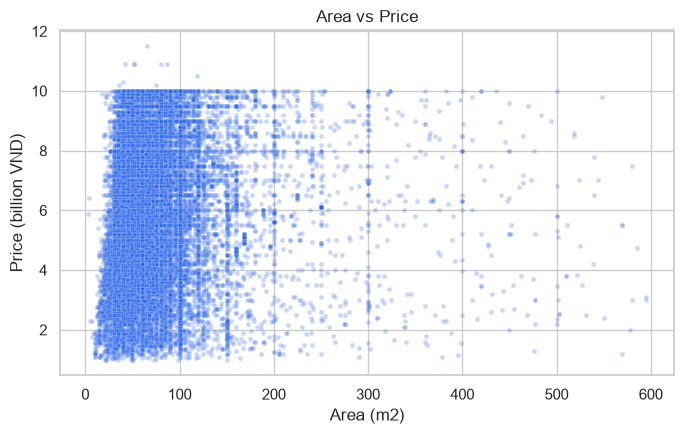

In [9]:
plt.figure(figsize=(7, 4.5))
sns.scatterplot(x=X["Area"], y=y, alpha=0.25, s=12, color="#2563eb")
plt.title("Area vs Price")
plt.xlabel("Area (m2)"); plt.ylabel("Price (billion VND)")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/02_area_vs_price.png", dpi=120)
plt.show()

**Observation:** price increases with area but with wide dispersion at every area level.
**Interpretation:** area alone is not sufficient to determine price — location and legal
status also matter a great deal. **ML implication:** `Area` is kept as an important numeric
feature but must be combined with the categorical features (especially province).

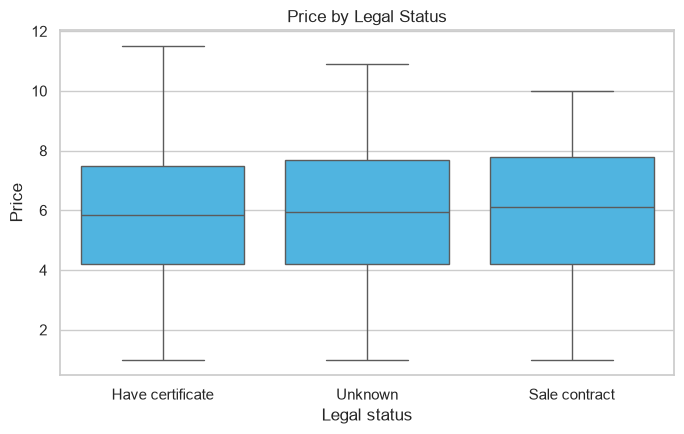

In [10]:
plt.figure(figsize=(7, 4.5))
sns.boxplot(x=df_clean["Legal status"], y=y, color="#38bdf8")
plt.title("Price by Legal Status")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/03_price_by_legal_status.png", dpi=120)
plt.show()

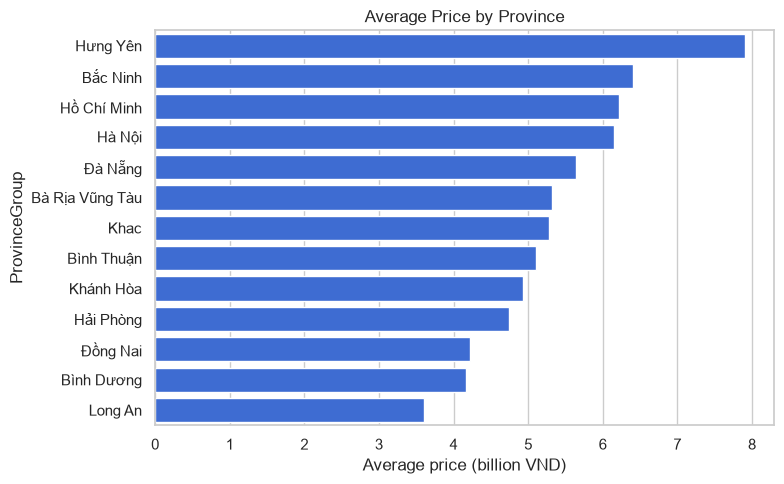

In [11]:
plt.figure(figsize=(8, 5))
avg_price = df_clean.groupby("ProvinceGroup")[target_col].mean().sort_values(ascending=False)
sns.barplot(x=avg_price.values, y=avg_price.index, color="#2563eb")
plt.title("Average Price by Province")
plt.xlabel("Average price (billion VND)")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/04_price_by_province.png", dpi=120)
plt.show()

**Observation:** average price differs noticeably between provinces (e.g. Hồ Chí Minh
and Hà Nội trade at a premium compared to smaller provinces). **ML implication:**
`ProvinceGroup` is expected to be one of the most informative categorical features and is
kept in the model, one-hot encoded.

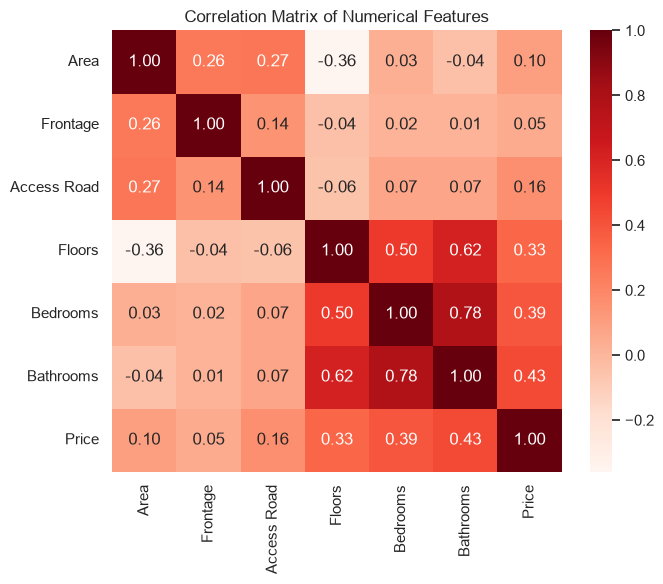

In [12]:
plt.figure(figsize=(7, 6))
corr = df_clean[numeric_features + [target_col]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Reds")
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/05_correlation_matrix.png", dpi=120)
plt.show()

## 6. Train / Validation / Test Split (70% / 15% / 15%)

The split is performed **before** any preprocessing is fit, to prevent data leakage.

In [13]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=RANDOM_SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED)
print("Train:", X_train.shape, " Validation:", X_val.shape, " Test:", X_test.shape)

Train: (21160, 11)  Validation: (4534, 11)  Test: (4535, 11)


## 7. Preprocessing Pipeline

- Numeric features: median imputation (learned on train only) + `StandardScaler`.
- Categorical features: most-frequent imputation + `OneHotEncoder(handle_unknown="ignore")`.
- The `ColumnTransformer` is **fit only on `X_train`**; `X_val`/`X_test` are only
  `.transform()`-ed, which prevents information from validation/test leaking into training.

In [14]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)
print("Processed shapes:", X_train_processed.shape, X_val_processed.shape, X_test_processed.shape)

Processed shapes: (21160, 43) (4534, 43) (4535, 43)


**Note on dimensionality:** the raw feature matrix has `d = 11` columns; after one-hot
encoding the five categorical columns, the processed matrix has many more columns (one per
category value). The exact number is printed above — this is the model-input dimension `d'`.

## 8. Baseline and Model Training

Baseline: `DummyRegressor(strategy="mean")` — always predicts the training-set mean price.
Five regression models are compared, following the assignment requirement:
Linear Regression, Ridge, Decision Tree, Random Forest, Gradient Boosting.

In [15]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train_processed, y_train)
baseline_metrics = regression_metrics(y_val, baseline.predict(X_val_processed))
print("Baseline validation metrics:", baseline_metrics)

Baseline validation metrics: {'MAE': 1.873490452727262, 'MSE': 4.960890050053587, 'RMSE': np.float64(2.2273055583043804), 'R2': -4.8448794008448814e-05}


In [16]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_SEED),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=RANDOM_SEED),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_SEED),
}

trained_models = {}
val_results = []
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_processed, y_train)
    train_time = time.time() - t0
    metrics = regression_metrics(y_val, model.predict(X_val_processed))
    metrics["Model"] = name
    metrics["Training Time (s)"] = train_time
    val_results.append(metrics)
    trained_models[name] = model

val_df = pd.DataFrame(val_results).set_index("Model")[["MAE", "MSE", "RMSE", "R2", "Training Time (s)"]]
val_df.sort_values("RMSE")

,MAE,MSE,RMSE,R2,Training Time (s)
Model,,,,,
Gradient Boosting,1.282547,2.636745,1.623806,0.468468,5.843435
Random Forest,1.264232,2.746908,1.657380,0.446260,2.058770
Decision Tree,1.370855,3.023929,1.738945,0.390417,0.069220
Ridge,1.479485,3.388387,1.840757,0.316947,0.014890
Linear Regression,1.479425,3.388421,1.840766,0.316940,0.030391


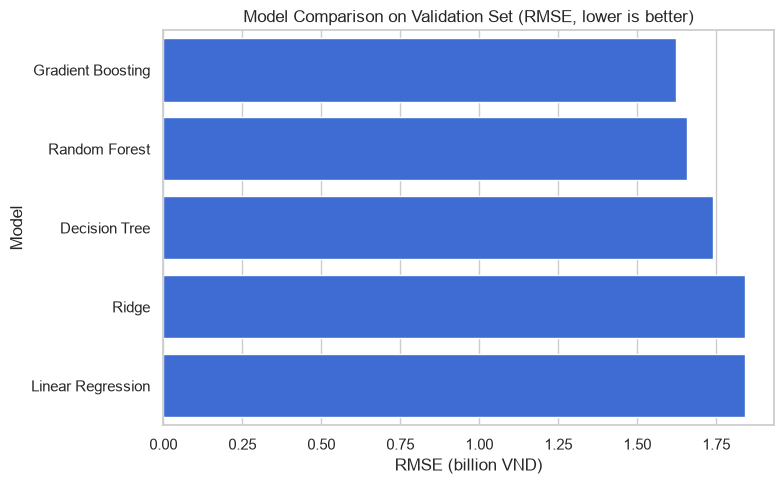

In [17]:
plt.figure(figsize=(8, 5))
sorted_df = val_df.sort_values("RMSE")
sns.barplot(x=sorted_df["RMSE"], y=sorted_df.index, color="#2563eb")
plt.title("Model Comparison on Validation Set (RMSE, lower is better)")
plt.xlabel("RMSE (billion VND)")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/06_model_comparison.png", dpi=120)
plt.show()

## 9. Model Selection and Test Evaluation

The model with the lowest **RMSE** on the validation set is selected and evaluated once,
finally, on the held-out **test** set — data that has never influenced training or model
selection.

In [18]:
best_model_name = val_df["RMSE"].idxmin()
best_model = trained_models[best_model_name]
print("Best model (validation RMSE):", best_model_name)

test_pred = best_model.predict(X_test_processed)
test_metrics = regression_metrics(y_test, test_pred)
test_metrics

Best model (validation RMSE): Gradient Boosting


{'MAE': 1.2478644137059527,
 'MSE': 2.5274382910619733,
 'RMSE': np.float64(1.589791901810414),
 'R2': 0.47200530995035395}

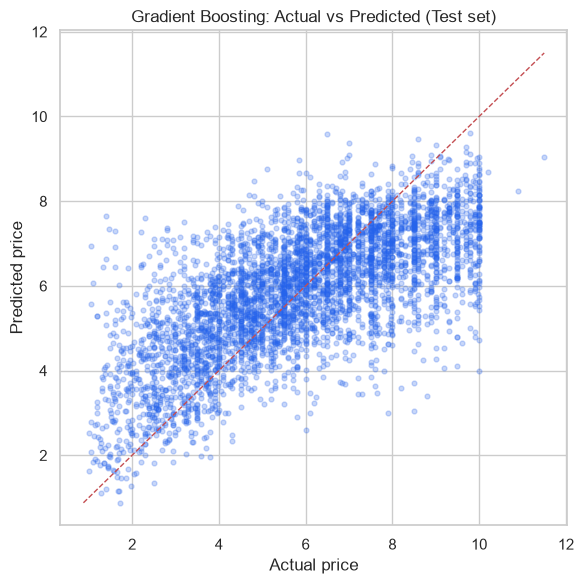

In [19]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_pred, alpha=0.25, s=12, color="#2563eb")
lims = [min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xlabel("Actual price"); plt.ylabel("Predicted price")
plt.title(f"{best_model_name}: Actual vs Predicted (Test set)")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/07_actual_vs_predicted_test.png", dpi=120)
plt.show()

## 10. Error Analysis

In [20]:
residuals = y_test.values - test_pred
error_df = pd.DataFrame({"actual": y_test.values, "predicted": test_pred, "abs_error": np.abs(residuals)})
print("Mean absolute error:", error_df["abs_error"].mean())
print("Median absolute error:", error_df["abs_error"].median())
error_df.sort_values("abs_error", ascending=False).head(5)

Mean absolute error: 1.2478644137059527
Median absolute error: 1.03131791763942


,actual,predicted,abs_error
4121,1.40,7.652901,6.252901
583,10.00,3.985234,6.014766
4175,1.05,6.948131,5.898131
676,1.46,7.352317,5.892317
1099,1.60,7.289263,5.689263


**Observation:** the largest errors occur on listings whose price is far from what their
`Area`/location profile would suggest — e.g. a small, cheaply-priced listing in an expensive
province, or a large discount/premium relative to comparable properties. **Interpretation:**
this indicates unobserved factors (interior finishing quality, exact street, seller
urgency) that are not captured by the available columns. **ML implication:** with only
tabular structural features (no photos, no exact geocoding), `R^2` around the low-to-mid
0.4s is a reasonable ceiling for this dataset, and is consistent with what real-estate
price-prediction literature typically reports for similarly limited feature sets.

## 11. Model Persistence

Both the fitted preprocessing pipeline **and** the fitted model are bundled into a single
`sklearn.Pipeline` and saved with `joblib`, so that the exact preprocessing used at training
time is guaranteed to be reused at inference time (no re-fitting on user input).

In [21]:
full_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model),
])
full_pipeline.fit(X_train, y_train)  # re-fit on train only, packaged as one object

joblib.dump(full_pipeline, f"{MODEL_DIR}/model_pipeline.joblib")

categorical_options = {c: sorted(df_clean[c].unique().tolist()) for c in categorical_features}
meta = {
    "app": "house_price",
    "best_model_name": best_model_name,
    "feature_cols": feature_cols,
    "numeric_cols": numeric_features,
    "categorical_cols": categorical_features,
    "categorical_options": categorical_options,
    "target_col": target_col,
    "target_unit": "billion VND",
    "test_metrics": test_metrics,
    "validation_comparison": val_df.reset_index().to_dict(orient="records"),
    "baseline_metrics": baseline_metrics,
    "random_seed": RANDOM_SEED,
}
with open(f"{MODEL_DIR}/meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("Saved model_pipeline.joblib and meta.json")

Saved model_pipeline.joblib and meta.json


## 12. Inference Test

Quick sanity check that the persisted pipeline can be loaded back and produce a prediction
on a brand-new, hand-written input row — exactly the code path the REST API uses.

In [22]:
loaded = joblib.load(f"{MODEL_DIR}/model_pipeline.joblib")
sample = pd.DataFrame([{
    "Area": 60, "Frontage": 4.5, "Access Road": 6, "Floors": 3,
    "Bedrooms": 3, "Bathrooms": 2, "Legal status": "Have certificate",
    "Furniture state": "Full", "House direction": "Đông - Nam",
    "Balcony direction": "Đông - Nam", "ProvinceGroup": "Hà Nội",
}])
print("Predicted price (billion VND):", loaded.predict(sample)[0])

Predicted price (billion VND): 5.923060940213547


## Discussion Questions (see report for full answers)

1. One observation = one real-estate listing (house/apartment).
2. Raw representation = CSV row with 12 columns, several with a large share of missing values.
3. Final numerical representation = a dense `float64` feature matrix produced by the
   `ColumnTransformer` (scaled numeric columns + one-hot categorical columns).
4. `N` = number of listings, `d` = number of columns in the encoded matrix.
5. Categorical: `Legal status`, `Furniture state`, `House direction`, `Balcony direction`,
   `ProvinceGroup` — all one-hot encoded.
6. Numeric: `Area`, `Frontage`, `Access Road`, `Floors`, `Bedrooms`, `Bathrooms` — all
   standardized.
7. Lost: the exact free-text address string, the raw string labels of categories
   (replaced by binary indicator columns).
8. Preserved: the numeric magnitude of every structural attribute (in standardized form),
   and the province/legal/furniture/orientation category of every listing.
9. Fitting the `StandardScaler`/`OneHotEncoder` on the full dataset (train+val+test) before
   splitting, or re-fitting them on user input at deployment time, would both leak
   information / break train-serve consistency.
10–13. See `model/meta.json` for the selected model, its metrics, and how it is persisted.
